<a href="https://colab.research.google.com/github/SalmanOkz/computer_vision/blob/main/computer_vision_lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# how do sift works
- Key point(intresteing points) [blob is a region of connected pixels in an image that share common properties ]
- KeyPoint localization (location of object)
- Orientaion (direction, where it lies in [x,y] )
- Keypoint Descriptor: 128 pixel (dimention)
- Second partial derivative
- surf uses integral images
- sift image ko different level pai blur kr k key point talash krta hai (DOG)
- key-point ko refine kr k exect location(x,y) scale(orientation) fix krta h
- hr key-point ki  (gradient direction)
- discriptor banata h (keypoint k ird gird ka area hota hai usko ak group mai rakhta h or usko lable kiya jata h [unique vector])  128 dmesional vectore hona chahiye wrna koi faida nh

# application [sift, surf]
- image matching
- object recognition
- reconstruction (3d model bnana)
## step 01
- integral images (x,y sum pixel)uses comulative sum, faster cal k liye hm sum value use krta h imges ki
- key_point detect krta h using hessian matrix (second partial derivative)
- orientation assign krta h using haar wavelet
- discriptor value 64

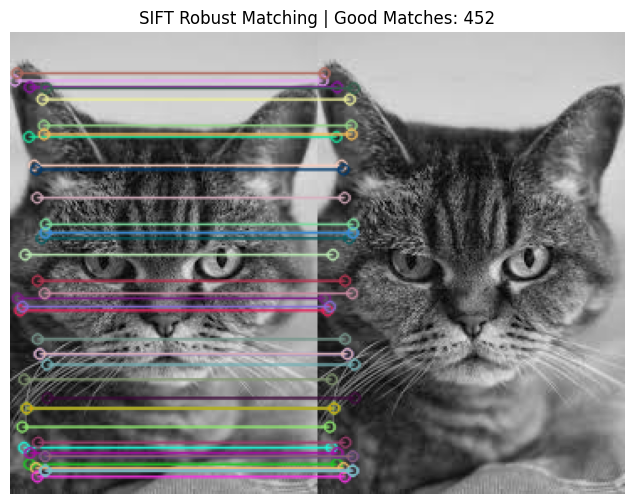

In [2]:
# Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Images
img1 = cv2.imread('/content/images.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/images.jpg', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    raise IOError("Error loading images")

# Initialize SIFT Detector
sift = cv2.SIFT_create(
    nfeatures=800,
    contrastThreshold=0.04,
    edgeThreshold=10,
    sigma=1.6
)

# Detect Keypoints and Descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Brute Force Matcher (L2 Norm)
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# KNN Matching
matches = bf.knnMatch(des1, des2, k=2)

# Lowe's Ratio Test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw Matches
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches[:40],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Visualization
plt.figure(figsize=(15, 6))
plt.imshow(matched_img, cmap='gray')
plt.title(f'SIFT Robust Matching | Good Matches: {len(good_matches)}')
plt.axis('off')
plt.show()